In [1]:
import sys
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt

# Make plots look a bit nicer
%matplotlib inline

# ---- Adjust these paths if needed ----
PROJECT_ROOT = Path("..")          # or Path("..") if notebook is in /notebooks
SCRIPT_PATH  = PROJECT_ROOT / "src" / "helpers_superpixel.py"

print("Project root:", PROJECT_ROOT.resolve())
print("Script path: ", SCRIPT_PATH.resolve())

# ---- Dynamically import functions from your script ----
import importlib.util

spec = importlib.util.spec_from_file_location("spx_graph", SCRIPT_PATH)
spx_graph = importlib.util.module_from_spec(spec)
sys.modules["spx_graph"] = spx_graph
spec.loader.exec_module(spx_graph)

compute_vesselness      = spx_graph.compute_vesselness
build_superpixels       = spx_graph.build_superpixels
adjacency_from_labels   = spx_graph.adjacency_from_labels
select_seeds            = spx_graph.select_seeds

print("Loaded functions from superpixel_graph_construction.py")


Project root: C:\Users\Asus\OneDrive\Desktop\ML_Project\Retina_SEM
Script path:  C:\Users\Asus\OneDrive\Desktop\ML_Project\Retina_SEM\src\helpers_superpixel.py
Loaded functions from superpixel_graph_construction.py


In [2]:
from typing import Dict

# Path to preprocessed data from Step 1
PRE_ROOT = PROJECT_ROOT / "preprocessed"

SPLIT = "train"   # "train" / "val" / "test"
IMAGE_INDEX = 0   # which image in that split we want to inspect

# Where to save graph .npz files (expected Step 2 output)
GRAPH_OUT_ROOT = PROJECT_ROOT / "outputs_graph"
GRAPH_OUT_ROOT.mkdir(exist_ok=True, parents=True)

img_dir = PRE_ROOT / SPLIT / "images"
fov_dir = PRE_ROOT / SPLIT / "fov_masks"

image_paths = sorted(img_dir.glob("*.png"))
print(f"Found {len(image_paths)} images in {img_dir}")

if len(image_paths) == 0:
    raise RuntimeError("No preprocessed images found. Check PRE_ROOT and SPLIT")

img_path = image_paths[IMAGE_INDEX]
fov_path = fov_dir / img_path.name

print("Using image:", img_path.name)
print("Image path:", img_path)
print("FOV path:  ", fov_path)


Found 480 images in ..\preprocessed\train\images
Using image: 100_A.png
Image path: ..\preprocessed\train\images\100_A.png
FOV path:   ..\preprocessed\train\fov_masks\100_A.png


Image shape: (1024, 1024)


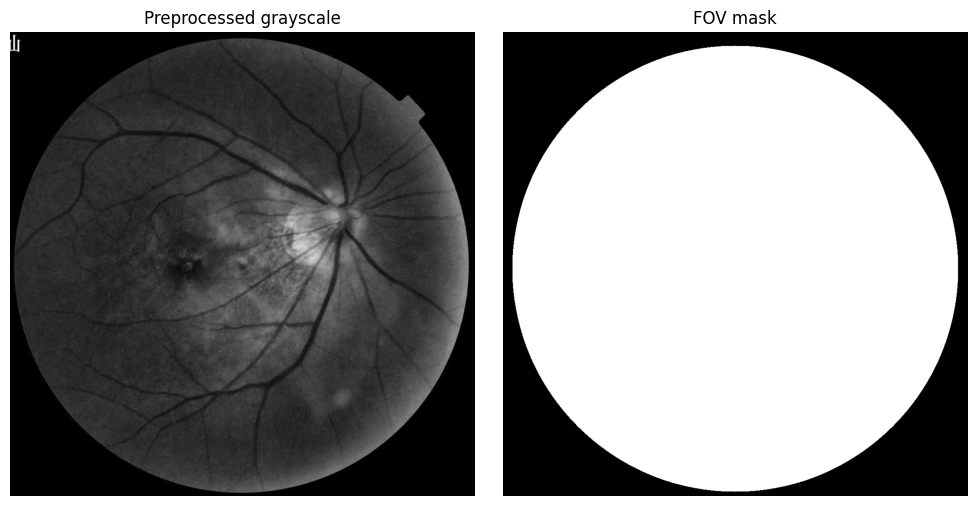

In [3]:
gray_u8 = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
fov_u8  = cv2.imread(str(fov_path), cv2.IMREAD_GRAYSCALE)

if gray_u8 is None:
    raise RuntimeError(f"Could not read {img_path}")
if fov_u8 is None:
    raise RuntimeError(f"Could not read {fov_path}")

print("Image shape:", gray_u8.shape)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(gray_u8, cmap="gray")
axs[0].set_title("Preprocessed grayscale")
axs[0].axis("off")

axs[1].imshow(fov_u8, cmap="gray")
axs[1].set_title("FOV mask")
axs[1].axis("off")

plt.tight_layout()
plt.show()


Vesselness: min = 0.0 max = 8.844875992508605e-06


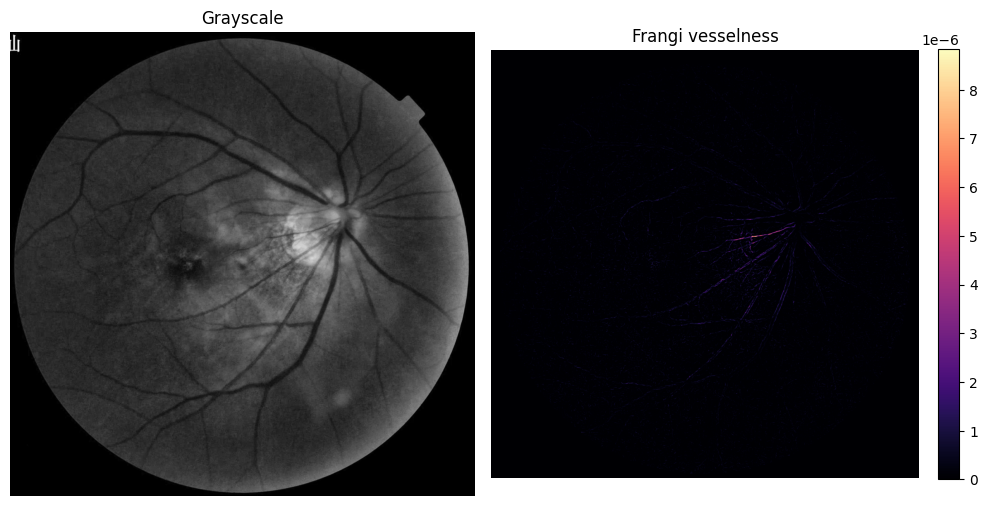

In [4]:
# You can tweak these hyperparams to match your script config
FRANGI_BETA  = 0.5
FRANGI_GAMMA = 15.0

vn = compute_vesselness(gray_u8, fov_u8, frangi_beta=FRANGI_BETA, frangi_gamma=FRANGI_GAMMA)
print("Vesselness: min =", float(vn.min()), "max =", float(vn.max()))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(gray_u8, cmap="gray")
axs[0].set_title("Grayscale")
axs[0].axis("off")

im = axs[1].imshow(vn, cmap="magma")
axs[1].set_title("Frangi vesselness")
axs[1].axis("off")
fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


Number of superpixels (K): 1496


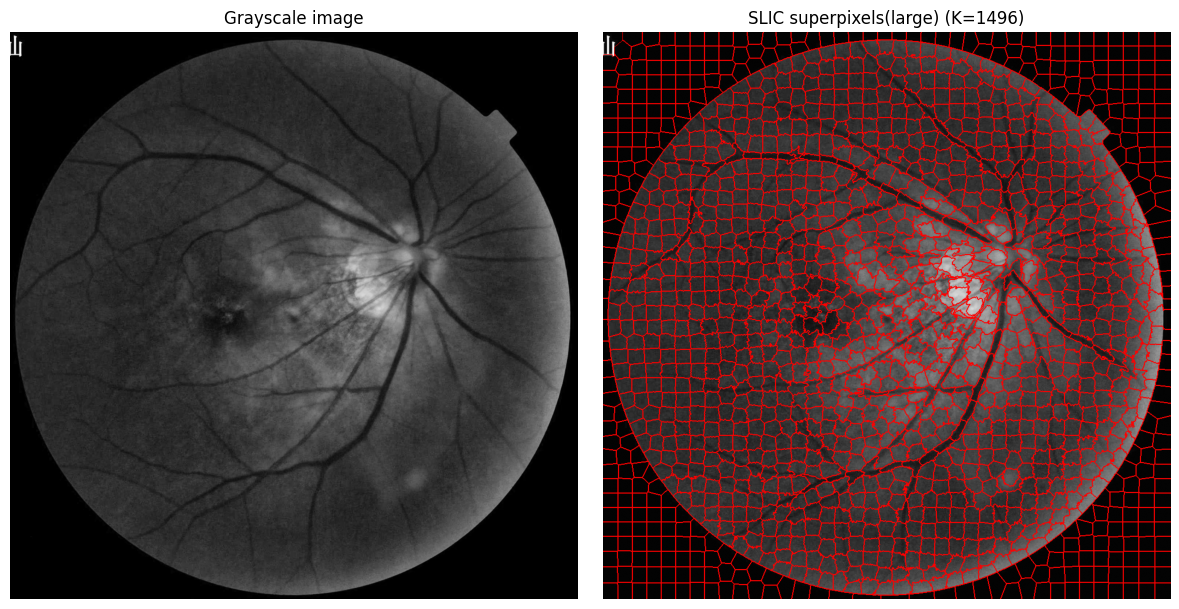

In [5]:
# Superpixel hyperparams (single scale for now; multi-scale can be added later)
N_SEGMENTS   = 1500
COMPACTNESS  = 10

labels, K = build_superpixels(gray_u8, n_segments=N_SEGMENTS, compactness=COMPACTNESS, sigma=0)
print("Number of superpixels (K):", K)

from skimage.segmentation import mark_boundaries

# mark_boundaries wants RGB
rgb = cv2.cvtColor(gray_u8, cv2.COLOR_GRAY2RGB)
bound_vis = mark_boundaries(rgb, labels, color=(1, 0, 0))  # red boundaries

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(gray_u8, cmap="gray")
axs[0].set_title("Grayscale image")
axs[0].axis("off")

axs[1].imshow(bound_vis)
axs[1].set_title(f"SLIC superpixels(large) (K={K})")
axs[1].axis("off")

plt.tight_layout()
plt.show()

In [7]:
from typing import Dict
import numpy as np

def build_graph_from_superpixels(
    gray_u8: np.ndarray,
    vn: np.ndarray,
    labels: np.ndarray,
    fg_seed_px: np.ndarray,
    bg_seed_px: np.ndarray,
    fg_thresh: float = 0.05,
    bg_thresh: float = 0.05
) -> Dict[str, np.ndarray]:
    H, W = gray_u8.shape
    K = int(labels.max()) + 1

    features   = np.zeros((K, 4), dtype=np.float32)
    centroids  = np.zeros((K, 2), dtype=np.float32)
    node_seeds = np.full(K, -1, dtype=np.int8)  # -1=unknown, 0=BG, 1=FG

    for k in range(K):
        mask = (labels == k)
        if not mask.any():
            continue

        ys, xs = np.where(mask)
        cy = ys.mean()
        cx = xs.mean()

        mean_intensity = float(gray_u8[mask].mean()) / 255.0
        mean_vn        = float(vn[mask].mean()) if (vn[mask].size > 0) else 0.0

        features[k, 0]  = mean_intensity
        features[k, 1]  = mean_vn
        features[k, 2]  = cy / H
        features[k, 3]  = cx / W

        centroids[k, 0] = cy
        centroids[k, 1] = cx

        # ----- node-level seeding -----
        n_pix   = mask.sum()
        fg_pix  = int((fg_seed_px[mask] > 0).sum())
        bg_pix  = int((bg_seed_px[mask] > 0).sum())

        fg_frac = fg_pix / n_pix
        bg_frac = bg_pix / n_pix

        if (fg_frac >= fg_thresh) and (fg_frac > bg_frac):
            node_seeds[k] = 1
        elif (bg_frac >= bg_thresh) and (bg_frac > fg_frac):
            node_seeds[k] = 0
        else:
            node_seeds[k] = -1

    # ---- build adjacency INSIDE the function ----
    adj = spx_graph.adjacency_from_labels(labels)

    edges_u, edges_v = [], []
    for u, nbrs in enumerate(adj):
        for v in nbrs:
            if v > u:
                edges_u.append(u)
                edges_v.append(v)

    edges = np.vstack(
        [np.array(edges_u, dtype=np.int32),
         np.array(edges_v, dtype=np.int32)]
    )

    return {
        "features":   features,
        "edges":      edges,
        "node_seeds": node_seeds,
        "centroids":  centroids,
    }


In [ ]:
# PARAMETERS 
fg_top_pct = 0.15
bg_low_pct = 0.15
ring_px    = 8

# Compute vesselness 
vn = spx_graph.compute_vesselness(gray_u8, fov_u8, frangi_beta=0.5, frangi_gamma=15.0)

# Compute seeds
fg_seed_px, bg_seed_px = spx_graph.select_seeds(
    vn,
    fov_u8,
    labels,
    fg_top_pct=fg_top_pct,
    bg_low_pct=bg_low_pct,
    ring_px=ring_px
)

print("FG seed count:", (fg_seed_px > 0).sum())
print("BG seed count:", (bg_seed_px > 0).sum())


FG seed count: 113559
BG seed count: 150283


In [9]:
graph_dict = build_graph_from_superpixels(gray_u8, vn, labels, fg_seed_px, bg_seed_px)

print("Feature matrix shape:", graph_dict["features"].shape)
print("Edges shape:", graph_dict["edges"].shape)
print("Node seeds counts:",
      {v: int((graph_dict["node_seeds"] == v).sum()) for v in [-1, 0, 1]})

Feature matrix shape: (1496, 4)
Edges shape: (2, 4230)
Node seeds counts: {-1: 363, 0: 657, 1: 476}


Graph: 1496 nodes, 4230 edges


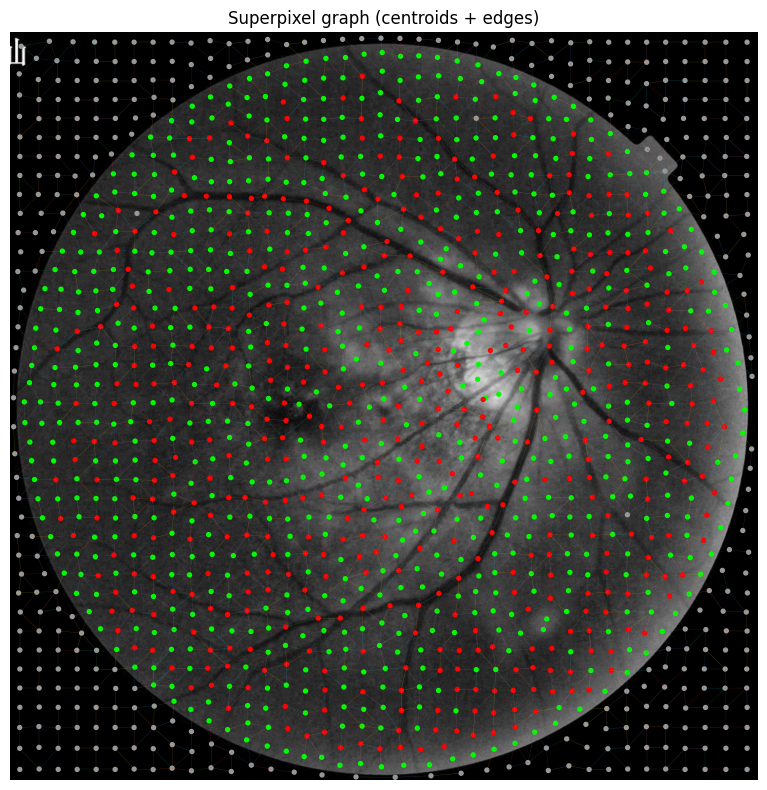

In [10]:
features   = graph_dict["features"]
edges      = graph_dict["edges"]
node_seeds = graph_dict["node_seeds"]
centroids  = graph_dict["centroids"]

K = features.shape[0]
E = edges.shape[1]

print(f"Graph: {K} nodes, {E} edges")

# Prepare colors for seeds
colors = np.zeros((K, 3), dtype=np.float32)
# unknown = gray
colors[node_seeds == -1] = [0.6, 0.6, 0.6]
# bg = green
colors[node_seeds == 0]  = [0.0, 1.0, 0.0]
# fg = red
colors[node_seeds == 1]  = [1.0, 0.0, 0.0]

# Subsample edges for plotting if too many
max_edges_to_plot = 2000
if E > max_edges_to_plot:
    idx = np.random.choice(E, size=max_edges_to_plot, replace=False)
    edges_vis = edges[:, idx]
else:
    edges_vis = edges

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(gray_u8, cmap="gray")
ax.set_title("Superpixel graph (centroids + edges)")
ax.axis("off")

# Draw edges
for u, v in edges_vis.T:
    y1, x1 = centroids[u]
    y2, x2 = centroids[v]
    ax.plot([x1, x2], [y1, y2], linewidth=0.3, alpha=0.3)

# Draw nodes (centroids)
ax.scatter(centroids[:, 1], centroids[:, 0], s=8, c=colors)

plt.tight_layout()
plt.show()
